In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.linalg import eigh_tridiagonal
import matplotlib.pyplot as plt
from itertools import combinations

# Contents
**Contents**

| § | Topic |
|---|---|
| 0 | Tutorial on the Lanczos algorithm |
| 1 | Problem 1: Free fermion chain  |
| 2 | Problem 2: Fermi-Hubbard model |

# 0. Tutorial: Lanczos algorithm
Below is a toy implementation of the Lanczos algorithm. Using the helper functions below, and making use of dense and sparse diagonalization routines in numpy and scipy, we will: 

a) test the convergence of the lowest eigenvalues obtained using the Lanczos iterative routine to the numerically exact eigenvalues$^*$.

b) show that the residual corresponding to a few low eigenvalues goes to zero.

$^*:$ These "numerically exact eigenvalues" could be either those we set ourselves (see the function "hermitian_with_spectrum" below), or those obtained using full numerical diagonalization (by using, for example "np.linalg.eigh"). Note that sparse diagonalization based on the iterative Lanczos algorithm is already implemented (ARPACK) as "spla.eigsh".

In [2]:
# Helper functions to build Hermitian (sparse and dense) matrices
def hermitian_with_spectrum(eigenvalues, seed=0, dtype=np.complex128):
    """Dense complex Hermitian matrix with *exactly* the requested spectrum.
    H = Q diag(lambda) Q^dagger with Q Haar-distributed unitary.  This is the
    workhorse for controlled experiments: the reference answer is known
    analytically, so measured errors are not contaminated by the reference.
    """
    lam = np.asarray(eigenvalues, dtype=np.float64)
    D = lam.size
    rng = np.random.default_rng(seed)
    Z = (rng.normal(size=(D, D)) + 1j * rng.normal(size=(D, D))) / np.sqrt(2)
    Q, R = np.linalg.qr(Z)
    Q = Q * (np.diag(R) / np.abs(np.diag(R)))          # fix the QR phase -> Haar measure
    return ((Q * lam) @ Q.conj().T).astype(dtype)


def hermiticity_error(H):
    """||H - H^dagger||_F / ||H||_F -- always check this before diagonalising."""
    if sp.issparse(H):
        D = H - H.conj().T
        return spla.norm(D) / spla.norm(H)
    return np.linalg.norm(H - H.conj().T) / np.linalg.norm(H)

# Sanity-check the check itself, on a matrix we will actually use later.
lam_demo = np.linspace(-2.0, 3.0, 400)
H_demo = hermitian_with_spectrum(lam_demo, seed=1)
print(f"400x400, prescribed spectrum on [{lam_demo[0]:+.1f}, {lam_demo[-1]:+.1f}]")
print(f"  ||H - H^dag||_F / ||H||_F      {hermiticity_error(H_demo):.2e}   <- O(eps): fine")
print(f"  largest |Im H_jj|              {np.abs(H_demo.diagonal().imag).max():.2e}"
      f"   <- diagonal of a Hermitian matrix is real")
print(f"  eigvalsh error vs prescribed   {np.abs(np.linalg.eigvalsh(H_demo) - lam_demo).max():.2e}")
print("\nNote the hermiticity error is small but *not* zero: Q diag(lam) Q^dag is only")
print("Hermitian up to roundoff.")

400x400, prescribed spectrum on [-2.0, +3.0]
  ||H - H^dag||_F / ||H||_F      2.83e-16   <- O(eps): fine
  largest |Im H_jj|              2.16e-17   <- diagonal of a Hermitian matrix is real
  eigvalsh error vs prescribed   1.40e-14

Note the hermiticity error is small but *not* zero: Q diag(lam) Q^dag is only
Hermitian up to roundoff.


In [3]:
# Three helper functions for the Lanczos routine
def _matvec_and_dim(H, dtype):
    """
        Return (matvec, D), casting H to `dtype` if it is not already of dtype.
        
        matvec is a function, with 
        matvec(v) = H @ v for three different data types used here.
        
        D is the dimension of H.
    """
    if sp.issparse(H) or isinstance(H, np.ndarray):
        Hc = H if H.dtype == dtype else H.astype(dtype)
        return (lambda x: Hc @ x), H.shape[0]
    if isinstance(H, spla.LinearOperator):
        return (lambda x: H.matvec(x)), H.shape[0]
    raise TypeError("H must be a numpy array, a scipy sparse matrix, or a LinearOperator")
    
def _randomvec( D, dtype=np.complex128, seed=0 ):
    '''
    Creates a D-element normalized random vector of type dtype. Will come in handy when implementing 
    Lanczos.
    '''
    rng = np.random.default_rng(seed)
    phi0 = rng.normal(size=D) + 1j * rng.normal(size=D)
    phi0 = np.asarray(phi0, dtype)
    phi0 = phi0 / np.linalg.norm(phi0)
    return phi0

def _project_out( Phid, n, gs_passes=2 ):
    '''
    Gram-Schmidt procedure, done gs_passes times
    '''
    for _ in range(gs_passes): # do this at least twice            
        h = Phid[:,:n+1].conj().T @ Phid[:,n+1] 
        # size check nxD times Dx1 is a nx1 vector of weigths,
        # i.e. inner products of the current vector with
        # the n basis vectors prior to it. Subtract the components 
        # of this vector onto the vectors prior to it.
        Phid[:,n+1] -= Phid[:,:n+1] @ h
        # size check: Dx1 on lhs and Dxn . nx1 = Dx1 on rhs

# lanczos_matrix        
def lanczos_matrix( H, d, phi0=None, dtype=np.complex128, gs_passes=2, return_evecs=True ): 
    '''
    Subroutine of the lanczos algorithm: Returns the elements of the Lanczos tridiagonal matrix,
    as alpha, and beta, along with the Krylov vectors. Note that the tridiagonla matrix should be 
    Hd whose diagonal is $alpha_0, ... ,alpha_{d-1}$, with d the size of the Krylov subspace, while 
    diagonal +/- 1 contains $ beta_{1}, ... , beta_{d-1}$.
    '''
    matvec, D  = _matvec_and_dim(H, dtype)
    
    alpha = np.zeros( d+1, dtype = dtype )
    beta  = np.zeros( d+1, dtype = dtype )
    Phid  = np.zeros( (D,d+1), dtype = dtype  )
    Phid[:,0] = phi0  # the first Krylov vector

    for n in range(0, d):
        phiprime = matvec(Phid[:,n]) 
        if (n>0): 
            phiprime -= beta[n] * Phid[:,n-1]
        alpha[n] = np.vdot(Phid[:,n], phiprime)
        phisecond = phiprime - alpha[n] * Phid[:,n]
        beta[n+1] = np.linalg.norm(phisecond)
        Phid[:,n+1] = phisecond/beta[n+1]
        
        # if gs_passes is zero
        _project_out( Phid, n, gs_passes=gs_passes )

    return {'alpha': alpha, # note one extra value of alpha, alpha[d] is returned
            'beta' : beta,  # analogous, beta[d] is also returned
            'Phid' : Phid if return_evecs else None }


def lanczos( H, d=10, phi0=None, k=0, dtype=np.complex128, seed=0, gs_passes=2 ):
    '''
    H: linear operator to diagonalize,
    d: dimension of the Krylov subspace,
    phi0: initial ket,
    k: number of eigenvectors to return
    dtype: data type for the entries of all arrays, defaults to numpy complex128
    seed: random number generator seed, should be an integer
    gs_passes: number of Gram-Schmidt passes. Set to 0 if you implement no reorthogonalization
    '''
    if phi0 == None:
        phi0 = _randomvec( np.shape(H)[0], dtype=dtype, seed=seed )
    lm = lanczos_matrix( H, d, phi0, dtype=dtype, gs_passes=gs_passes, return_evecs=True )
    
    # Ritz values theta[i] and Ritz vectors psi[i], for i = 0, ..., d-1
    theta, psi = ritz(lm, d)
    # psi[m,j] contains the the nth entry of the mth Ritz vector, and psi is a dxd matrix
    
    return {
            'theta': theta, # Ritz values
            'psi'  : psi,   # Ritz vectors
            'Psi'  : (lm['Phid'][:,:-1] @ psi)[:,:k] if k>0 else None, 
                            # a matrix containing the approximations to the first k eigenvectors, as obtained
                            # from the Ritz vectors
            'alpha': lm['alpha'], 
            'beta':  lm['beta']
           }

def ritz(lanczos_output, d=None):
    '''
    This returns the Ritz values and vectors from the output of the lanczos function, 
    at a given Krylov subspace dimension d. Useful for convergence tests.
    '''
    if d==None:
        d=len(lanczos_output['alpha'])
    theta, psi = eigh_tridiagonal( np.real(lanczos_output['alpha'][0:d]), 
                                   np.real(lanczos_output['beta'][1:d]) )
    return  theta, psi    # Ritz values and vectors

(1000, 1000)
Lowest Ritz value =  -1.499999999999999
 | H | Psi_0 > - theta_0 | Psi_0 > |= 4.262069651217103e-14
 < Psi_0 | H | Psi_0>/<Psi_0 | Psi_0> =  (-1.5-3.7296554733501486e-16j)
Full diagonalization, lowest eigenvalue =  [-1.5    2.     3.121  5.31   6.732]


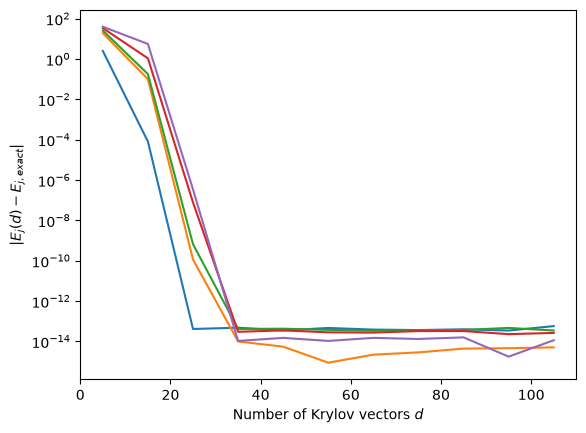

In [4]:
# Solution to a)

# quick checks: sample spectrum, 
D=1000
sample_spectrum = np.sort( np.concatenate((np.array([-1.5, 2.0, 3.121, 5.31, 6.732, 10.21, 12.7832]), 
                                           np.linspace(21.021, 49.0, D-7))) )
sample_H = hermitian_with_spectrum(sample_spectrum, seed=0, dtype=np.complex128)
print(np.shape(sample_H))
lanczos_data=lanczos( sample_H, 200, k=1, dtype=np.complex128, seed=1, gs_passes=2  ) 
print("Lowest Ritz value = ", lanczos_data['theta'][0])
print(" | H | Psi_0 > - theta_0 | Psi_0 > |=", 
      np.linalg.norm(sample_H @ lanczos_data['Psi'][:,0] - 
                     lanczos_data['theta'][0]* lanczos_data['Psi'][:,0])
     )

# One needs to be careful with the normalization
print(" < Psi_0 | H | Psi_0>/<Psi_0 | Psi_0> = ", 
      (lanczos_data['Psi'][:,0].conj().T @ sample_H @ lanczos_data['Psi'][:,0]) / 
      (lanczos_data['Psi'][:,0].conj().T  @ lanczos_data['Psi'][:,0])  
     )

ds = np.array(range(5,110,10))

firstk=5 # first k eigenvalues will be studied below

E0s= np.array([ritz(lanczos_data,d)[0][:firstk] for d in ds])
E0eigh= np.linalg.eigh(sample_H)[0][:firstk]
print("Full diagonalization, lowest eigenvalue = ", E0eigh)
%matplotlib inline
plt.plot( ds, np.abs(E0s-E0eigh))
plt.xlabel(r"Number of Krylov vectors $d$")
plt.ylabel(r"$|E_j(d) - E_{j,exact}|$")
plt.yscale('log')
plt.show()

#### Solution to b)
Recall from the lecture note that the residual is given by $|| \mathscr{H} \Psi_m - \theta_m \Psi_m|| = \beta_d | \psi_{m,d-1}|$, where on the rhs the second factor is the last component of the Ritz vector over Lanczos vectors $\phi_m$ for $m=0,\ldots,d-1$ of the $d-$dimensional Krylov subspace. Plot this quantity as function of the size of the Krylov subspace, $d$.

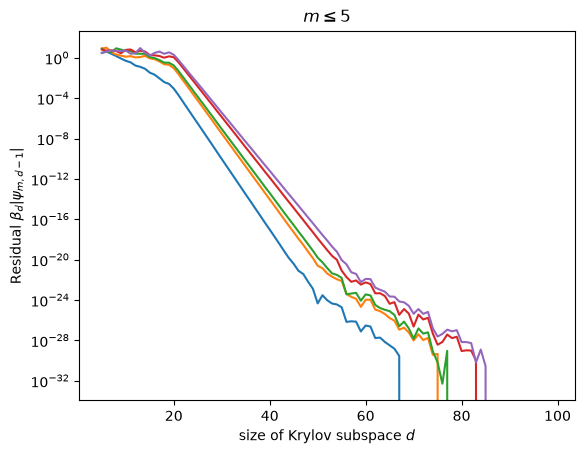

In [5]:
# Solution to b)
ds = np.arange(5,100,1)
residuals = []
firstk=5
for d in ds:
    lanczos_spectrum=lanczos( sample_H, d, k=2, dtype=np.complex128, seed=1, gs_passes=2 ) 
    betad = np.real(lanczos_spectrum['beta'][-1]) 
    # this is the d+1^th component of the beta vector -- i.e. it was computed 
    # but does not appear in the tridiagonal matrix that gives the Ritz values.
    residuals.append(betad*np.abs(lanczos_spectrum['psi'][-1,:firstk]))
    
%matplotlib inline
plt.plot( ds, np.array(residuals).astype(np.float64) )
plt.yscale('log')
plt.ylabel(r'Residual $\beta_d | \psi_{m,d-1}|$')
plt.xlabel(r'size of Krylov subspace $d$')
plt.title(r'$m \leq$'+str(firstk))
plt.show()

# 1. Problem: Implementation of a free fermion ring

In this problem, we implement the hamiltonian of a free fermion translationally symmetric $L-$site ring and compare to the analytically known energies in the $N$-particle sector. The Hamiltonian in second-quantized notation reads

$$
H = -t \sum_{j} \left( c^\dagger_{j+1} c_{j} + \mathrm{h.c.} \right).
$$

## Helper functions: Lin tables, bitstrings, and all that

In [6]:
# ================= bitstring primitives: one site index, one state ================
# Every one is a one-liner, but naming them fixes the argument order (site first,
# state second) and lets the Hamiltonian below read as physics, not bit twiddling.

def basis_states(L, N):
    """Occupation-number basis of the N-particle sector, as sorted bitstrings."""
    states = np.array(sorted(sum(1 << j for j in sites)
                             for sites in combinations(range(L), N)), dtype=np.int64)
    return states, {int(s): i for i, s in enumerate(states)}


def occ(j, s):
    """Is site j occupied in the bitstring state s?

    Example: s = 13, bin(s) = '0b1101', so occ(0, s) = 1 but occ(1, s) = 0.
    """
    return (s >> j) & 1


def c(j, s):
    """Remove a particle at site j: if the jth bit is 1 it is set to 0, else nothing.

    For that `else' the caller needs an external guardrail -- see h_fermion_ring.
    """
    return s & ~(1 << j)


def cdag(j, s):
    """Add a particle at site j: if the jth bit is 0 it is set to 1, else nothing.

    For that `else' the caller needs an external guardrail -- see h_fermion_ring.
    """
    return s | (1 << j)


def count_below(j, s):
    """Number of particles on sites with index strictly below j (Jordan-Wigner string).

    (1 << j) is 2^j; (1 << j) - 1 is 2^j - 1 = 2^0 + ... + 2^(j-1), i.e. a mask of
    ones on every site below j.  For j = 3 that is 1000 - 1 = 111.  The & then keeps
    only those sites of s, and .count("1") counts the particles among them.
    """
    return bin(s & ((1 << j) - 1)).count("1")


In [7]:
print(basis_states(4, 3))

(array([ 7, 11, 13, 14]), {7: 0, 11: 1, 13: 2, 14: 3})


In [8]:
[bin(state) for state in basis_states(4,3)[0]]

['0b111', '0b1011', '0b1101', '0b1110']

In [9]:
# ---------------------------------- Lin table example --------------------------------------
L_demo = 4
_st, _ix = basis_states(L_demo, 2)
print(f"basis_states({L_demo}, 2): the {len(_st)} = C({L_demo},2) two-particle states,"
      f" sorted ascending")
print(f"{'index':>7}{'integer':>9}{'bits':>8}{'occupied sites':>17}")
for k, st in enumerate(_st):
    st = int(st)
    print(f"{k:>7}{st:>9}{format(st, f'0{L_demo}b'):>8}"
          f"{str([j for j in range(L_demo) if occ(j, st)]):>17}")
print(f"  the second return value inverts that map: index[{int(_st[3])}] = {_ix[int(_st[3])]}")
print(f"  (bit 0 is the RIGHTMOST digit, so site 0 is the last character)\n")


basis_states(4, 2): the 6 = C(4,2) two-particle states, sorted ascending
  index  integer    bits   occupied sites
      0        3    0011           [0, 1]
      1        5    0101           [0, 2]
      2        6    0110           [1, 2]
      3        9    1001           [0, 3]
      4       10    1010           [1, 3]
      5       12    1100           [2, 3]
  the second return value inverts that map: index[9] = 3
  (bit 0 is the RIGHTMOST digit, so site 0 is the last character)



In [10]:
# ---------------------------------- example: c and cdag action on bitstrings----------------------
show = lambda s: format(s, f"0{L_demo}b")         # print bit 0 on the RIGHT
s = 0b1101                                        # sites 0, 2, 3 occupied
print(f"state s = {show(s)}  (= {s}),  sites occupied: "
      f"{[j for j in range(L_demo) if occ(j, s)]}\n")

print(f"{'j':>3}{'occ(j,s)':>10}{'c(j,s)':>9}{'cdag(j,s)':>12}{'count_below(j,s)':>19}")
for j in range(L_demo):
    print(f"{j:>3}{occ(j, s):>10}{show(c(j, s)):>9}{show(cdag(j, s)):>12}"
          f"{count_below(j, s):>19}")

print("\nThere are two situations where the operator c or cdag leaves the state bitstring intact:")
print(f"  c(1, {show(s)})    = {show(c(1, s))}   site 1 was already empty "
      f"-> unchanged. In implementation, this will have to carry over to the zero vector to correctly reflect annihilation.")
print(f"  cdag(0, {show(s)}) = {show(cdag(0, s))}   site 0 was already full  "
      f"-> unchanged, In implementation, this will have to carry over to the zero vector to correctly Pauli principle.")

state s = 1101  (= 13),  sites occupied: [0, 2, 3]

  j  occ(j,s)   c(j,s)   cdag(j,s)   count_below(j,s)
  0         1     1100        1101                  0
  1         0     1101        1111                  1
  2         1     1001        1101                  1
  3         1     0101        1101                  2

There are two situations where the operator c or cdag leaves the state bitstring intact:
  c(1, 1101)    = 1101   site 1 was already empty -> unchanged. In implementation, this will have to carry over to the zero vector to correctly reflect annihilation.
  cdag(0, 1101) = 1101   site 0 was already full  -> unchanged, In implementation, this will have to carry over to the zero vector to correctly Pauli principle.


In [11]:
print(f"\nfull hops  cdag_dst c_src  on s = {show(s)}:")
for src_, dst_ in ((3, 2), (0, 1),(2,1),(3,1)):
    ok = occ(src_, s) and not occ(dst_, s)
    print(f"\n  cdag_{dst_} c_{src_}:  occ({src_},s) = {occ(src_, s)},"
          f"  occ({dst_},s) = {occ(dst_, s)}  ->  {'apply' if ok else 'SKIP (Pauli exclusion principle)'}")
    if not ok:
        continue
    s1 = c(src_, s)
    sgn1 = (-1) ** count_below(src_, s)
    sgn2 = (-1) ** count_below(dst_, s1)
    print(f"    c({src_}, s)     : {show(s)} -> {show(s1)},"
          f"   count_below({src_}, s)  = {count_below(src_, s)}  -> {sgn1:+d}")
    print(f"    cdag({dst_}, s1) : {show(s1)} -> {show(cdag(dst_, s1))},"
          f"   count_below({dst_}, s1) = {count_below(dst_, s1)}  -> {sgn2:+d}")
    print(f"    total sign {sgn1 * sgn2:+d}")


full hops  cdag_dst c_src  on s = 1101:

  cdag_2 c_3:  occ(3,s) = 1,  occ(2,s) = 1  ->  SKIP (Pauli exclusion principle)

  cdag_1 c_0:  occ(0,s) = 1,  occ(1,s) = 0  ->  apply
    c(0, s)     : 1101 -> 1100,   count_below(0, s)  = 0  -> +1
    cdag(1, s1) : 1100 -> 1110,   count_below(1, s1) = 0  -> +1
    total sign +1

  cdag_1 c_2:  occ(2,s) = 1,  occ(1,s) = 0  ->  apply
    c(2, s)     : 1101 -> 1001,   count_below(2, s)  = 1  -> -1
    cdag(1, s1) : 1001 -> 1011,   count_below(1, s1) = 1  -> -1
    total sign +1

  cdag_1 c_3:  occ(3,s) = 1,  occ(1,s) = 0  ->  apply
    c(3, s)     : 1101 -> 0101,   count_below(3, s)  = 2  -> +1
    cdag(1, s1) : 0101 -> 0111,   count_below(1, s1) = 1  -> -1
    total sign -1


## The hamiltonian `h_fermion_ring` in pseudocode

With those primitives the whole Hamiltonian is four nested loops. In words: for every basis
state, for every bond, for both directions, apply $c^\dagger_{\rm dst} c_{\rm src}$ and
record where it lands and with what sign. Below is the pseudocode and you will have to **implement this**.

```
for each basis state s, at column index a:
    for each bond (j, k = j+1 mod L):
        for (src, dst, amp) in [ (j, k, -t),        # forward hop
                                 (k, j, -t) ]:      # its Hermitian partner

            if src is empty  or  dst is occupied:
                skip this term          # c|0> = 0, or cdag|1> = 0

            sign  = (-1)^( particles below src, counted in s  )   # string of c_src
            s1    = s with site src emptied                       # the INTERMEDIATE state
            sign *= (-1)^( particles below dst, counted in s1 )   # string of cdag_dst
            b     = index of ( s1 with site dst filled )

            H[b, a] += amp * sign
```

Use the following interface:
```python
def h_fermion_ring(L, N, t=1.0, dtype=np.complex128):
    """Hopping matrix for spinless fermions on an L-site ring, N-particle sector (CSR scipy matrix).
    Pure kinetic energy: -t sum_j c^dag_{j+1} c_j + h.c.), with Jordan-Wigner signs.
    """

    #
    #
    # Assign matrix elements (stored in sparse format as shown in the line right below) 
    # according to the pseudocode above. 
    #
    #
    
    H = sp.coo_matrix((vals, (rows, cols)), shape=(dim, dim), dtype=np.complex128).tocsr()
    H.sum_duplicates()
    return H.astype(dtype), states

```

The helper function implemented below, 
```python
def free_fermion_E0(L, N, t=1.0):
        """Exact ground-state energy of the non-interacting on a flux-threaded ring: fill the N lowest levels."""
    ...
```
will come in handy as you are checking your implementation.

In [12]:
def free_fermion_E0(L, N, t=1.0):
    """Exact ground-state energy of the non-interacting on a flux-threaded ring: fill the N lowest levels."""
    eps = -2.0 * t * np.cos((2 * np.pi * np.arange(L)) / L)
    return np.sort(eps)[:N].sum()

In [32]:
states, indices = basis_states(4, 3)
indices
# for i in range(3):
#     print(i)
# count_below(3,8)
# occ()
for (a, b) in [(1,2), (3,4)]:
    print(a, b)
# for i in indices:
#     print(i, indices[i])
# for [i, j] in zip(states, indices):
#     print(i, j)

1 2
3 4


In [13]:
# solution: implementation of h_fermion_ring according to the interface above
def h_fermion_ring(L, N, t=1.0, dtype=np.complex128):
    """Hopping matrix for spinless fermions on an L-site ring threaded by flux, N-particle sector (CSR scipy matrix).
    Pure kinetic energy: -t sum_j c^dag_{j+1} c_j + h.c.), with
    Jordan-Wigner signs.
    """
    states, indices = basis_states(L, N)
    dim = len(states)
    rows, cols, vals = [], [], []

    for s in indices:
        i = indices[s]
        for j in range(L):
            k = (j+1) % L
            for (src, dst) in [(j, k), (k, j)]:
                if not occ(src, s) or occ(dst, s):
                    continue
                sign = (-1)**count_below(src, s)
                s1 = c(src, s)
                sign *= (-1)**count_below(dst, s1)
                b = indices[cdag(dst, s1)]
                rows.append(b)
                cols.append(i)
                vals.append(-t * sign)
                
    #
    #
    # Assign matrix elements (stored in sparse format as shown in the line right below) 
    # according to the pseudocode above. 
    #
    #

    H = sp.coo_matrix((vals, (rows, cols)), shape=(dim, dim), dtype=np.complex128).tocsr()
    H.sum_duplicates()
    return H.astype(dtype), states

In [14]:
H_mb = h_fermion_ring(4, 2, 1)[0]
H_mb.toarray()

array([[ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [-1.+0.j,  0.+0.j, -1.+0.j, -1.+0.j,  0.+0.j,  1.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 1.+0.j,  0.+0.j, -1.+0.j, -1.+0.j,  0.+0.j, -1.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j]])

## Physics questions for Problem 1
a) Check that the ground state energy matches the analytical form as well as that returned by full diagonalization with sample call (if the Hamiltonian is stored in sparse matrix `H_mb')
```python
E_full = np.linalg.eigvalsh(H_mb.toarray())[0]
```
and ARPACK sparse diagonalization
```python
E_arpk = spla.eigsh(H_mb, k=1, which="SA", tol=0, return_eigenvectors=False)[0]
```
b) Plot the error towards the exact ground state energy versus number of Krylov vectors, and the ground state energy versus flux obtained from Lanczos and from the analytical formula. 

In [15]:
# Solution for a) Simple checks
L = 10
N = 5
t = 1
H_mb = h_fermion_ring(L, N, t)[0]
E_full = np.linalg.eigvalsh(H_mb.toarray())[0]
E_arpk = spla.eigsh(H_mb, k=1, which="SA", tol=0, return_eigenvectors=False)[0]

E_ED = free_fermion_E0(L, N, t)

(E_full, E_arpk, E_ED)

(np.float64(-6.472135954999582),
 np.float64(-6.472135954999605),
 np.float64(-6.47213595499958))

Lowest Ritz value =  -6.472135954999583
 | H | Psi_0 > - theta_0 | Psi_0 > |= 5.6926752497849606e-15
 < Psi_0 | H | Psi_0>/<Psi_0 | Psi_0> =  (-6.472135954999575-1.1102230246251548e-16j)
Full diagonalization, lowest eigenvalue =  [-1.5    2.     3.121  5.31   6.732]


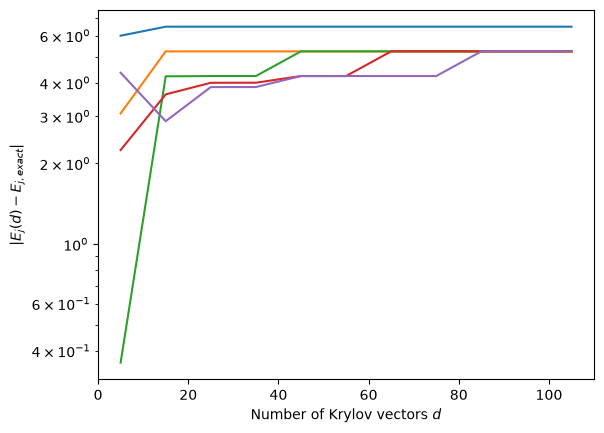

In [67]:
# Solution for b) Plots
# --- benchmark: Lanczos vs full ED on the many-body Hamiltonian ------------------
lanczos_data=lanczos( H_mb, 200, k=1, dtype=np.complex128, seed=1, gs_passes=2  ) 
print("Lowest Ritz value = ", lanczos_data['theta'][0])
print(" | H | Psi_0 > - theta_0 | Psi_0 > |=", 
      np.linalg.norm(H_mb @ lanczos_data['Psi'][:,0] - 
                     lanczos_data['theta'][0]* lanczos_data['Psi'][:,0])
     )

# One needs to be careful with the normalization
print(" < Psi_0 | H | Psi_0>/<Psi_0 | Psi_0> = ", 
      (lanczos_data['Psi'][:,0].conj().T @ H_mb @ lanczos_data['Psi'][:,0]) / 
      (lanczos_data['Psi'][:,0].conj().T  @ lanczos_data['Psi'][:,0])  
     )

ds = np.array(range(5,110,10))

firstk=5 # first k eigenvalues will be studied below

E0s= np.array([ritz(lanczos_data,d)[0][:firstk] for d in ds])
# E0eigh= np.linalg.eigh(H_mb)[0][:firstk]
print("Full diagonalization, lowest eigenvalue = ", E0eigh)
%matplotlib inline
plt.plot( ds, np.abs(E0s))
plt.xlabel(r"Number of Krylov vectors $d$")
plt.ylabel(r"$|E_j(d) - E_{j,exact}|$")
plt.yscale('log')
plt.show()

# 2. Problem: One-dimensional Fermi-Hubbard model

## Preamble
Add spin and an on-site interaction:

$$
H = -t \sum_{j,\sigma} \left( c^\dagger_{j+1,\sigma} c_{j,\sigma}
    + \mathrm{h.c.} \right)
    \;+\; U \sum_{j} n_{j\uparrow} n_{j\downarrow},
\qquad \sigma \in \{\uparrow,\downarrow\}.
$$

#### The Hilbert space factorises

As explained in lecture 1, $N_\uparrow$ and $N_\downarrow$ are separately conserved, so the sector is a **tensor
product**

$$\mathcal{H} = \mathcal{H}_\uparrow \otimes \mathcal{H}_\downarrow,
\qquad
D = D_\uparrow D_\downarrow = \binom{L}{N_\uparrow}\binom{L}{N_\downarrow},$$

and we index it as

$$\boxed{\;I \;=\; I_\uparrow\, D_\downarrow \;+\; I_\downarrow\;}$$

where $I_\sigma$ is the position of that species' bitstring in the *single-species* basis introduced for the free fermion chain above. 

#### A worked example: $L = 3$, $N_\uparrow = 2$, $N_\downarrow = 1$

Small enough to write out completely. Each species gets its own basis from
`basis_states`, as $L$-bit integers sorted ascending:

| $I_\uparrow$ | $s_\uparrow$ | occupied | | $I_\downarrow$ | $s_\downarrow$ | occupied |
|---|---|---|---|---|---|---|
| 0 | `011` | sites 0, 1 | | 0 | `001` | site 0 |
| 1 | `101` | sites 0, 2 | | 1 | `010` | site 1 |
| 2 | `110` | sites 1, 2 | | 2 | `100` | site 2 |

so $D_\uparrow = D_\downarrow = 3$ and $D = 9$. 

The composite index runs $I = 3 I_\uparrow + I_\downarrow$:

| $I$ | $I_\uparrow$ | $I_\downarrow$ | $s_\uparrow$ | $s_\downarrow$ | $\sum_j n_{j\uparrow}n_{j\downarrow}$ |
|---|---|---|---|---|---|
| 0 | 0 | 0 | `011` | `001` | 1 |
| 1 | 0 | 1 | `011` | `010` | 1 |
| 2 | 0 | 2 | `011` | `100` | 0 |
| 3 | 1 | 0 | `101` | `001` | 1 |
| 4 | 1 | 1 | `101` | `010` | 0 |
| 5 | 1 | 2 | `101` | `100` | 1 |
| 6 | 2 | 0 | `110` | `001` | 0 |
| 7 | 2 | 1 | `110` | `010` | 1 |
| 8 | 2 | 2 | `110` | `100` | 1 |

The last column — the double occupancy — is just `popcount(s_up & s_dn)`, i.e. counts double occupancies. 


#### Implementation of matrix-vector multiplication in this basis representation

Place the nine amplitudes as a $D_\uparrow \times D_\downarrow$ grid
$\Psi[I_\uparrow, I_\downarrow]$

$$
\Psi \;=\;
\begin{array}{c|ccc}
 & s_\downarrow = \texttt{001} & \texttt{010} & \texttt{100} \\ \hline
s_\uparrow = \texttt{011} & \psi_0 & \psi_1 & \psi_2 \\
\texttt{101} & \psi_3 & \psi_4 & \psi_5 \\
\texttt{110} & \psi_6 & \psi_7 & \psi_8
\end{array}
$$

$H$ will consist of three terms, two hopping operators for each spin flavor and one for the Hubbard interaction, each with a simple action on this grid

```python
def matvec(x):
    P = x.reshape(Du, Dd)
    return (Hup @ P + (Hdn @ P.T).T).ravel() + (U * docc) * x
```

where the double occupancy array simply counts doubly occupied sites between the two bitstrings

```python
# docc[a, b] = number of doubly occupied sites in |s_up[a]> (x) |s_dn[b]>
docc = np.array([[bin(int(a) & int(b)).count("1") for b in s_dn]
                 for a in s_up], dtype=np.float64).ravel()
```

In the implementation of `docc`, `.ravel()` will flatten the matrix, and `s_up` and `s_dn` are state bitstrings as created by `h_fermion_ring`. NumPy flattens row-major, so entry `[a, b]` lands at position `a * Dd + b` — which is exactly $I = I_\uparrow D_\downarrow + I_\downarrow$. 

The implementation of the matvec required for the hubbard Hamiltonian thus contains two sparse matrix products of size $D_\sigma$ and one elementwise multiply, in place of a single $D \times D$ product.

## Task list
a) Implement the Hubbard Hamiltonian as a sparse matrix according to the following interface

```python
def hubbard_operator(L, Nup, Ndn, t=1.0, U=0.0):
    """
        Matrix-free Fermi-Hubbard H in the (Nup, Ndn) sector.
        Returns (LinearOperator, double-occupancy diagonal, (D_up, D_dn)).
    """

    #
    #
    # your implementation goes here: you should define Hup, Hdn, docc
    #
    #
    
    def matvec(x):
        P = x.reshape(Du, Dd)
        return (Hup @ P + (Hdn @ P.T).T).ravel() + (U * docc) * x

    return spla.LinearOperator((Du * Dd, Du * Dd), matvec=matvec,
                               dtype=np.complex128), docc, (Du, Dd)
```

b) Check your implementation against the analytical two-site solution done in class, using the two-site functions provided in the cell below: `dimer_block_11`, `dimer_spectrum`, and `E0_dimer`.

c) Focus on a small case at half-filling, with total $S_z=0$, namely `L, Nup, Ndn = 10, 5, 5`. 

- Plot the ground state energy error as a function of the number of Krylov vectors, 

- Plot the double occupancy $\langle n_\uparrow \rangle \langle n_\downarrow \rangle$ in the ground state as a function of $U/t$, 

- and the charge gap $E_0^{N+1} + E_0^{N-1} - 2E_0^{N}$. You may use `t=1.0` for the hopping and the following array `Us = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 12.0, 16.0, 32.0, 64.0 ])` for the Hubbard interaction.

- Plot the ground state energy as a function of $U/t$ and interpret the limit $U/t \to \infty$. What is the degeneracy of the ground state in this limit? Is there any numerical evidence of degeneracy?

- By timing your runs compare the performance of the Lanczos routine versus full diagonalization of the dense matrix, as function of Hilbert space size -- you can choose to stay at half filling but increase the length of the chain, for example. How does the computation time scale with Hilbert space dimension?

In [ ]:
def dimer_block_11(U, t):
    """The (N_up, N_dn) = (1,1) block, written out by hand in the |A>,|B>,|C>,|D> basis."""
    return np.array([[U, -t, -t,  0],
                     [-t,  0,  0, -t],
                     [-t,  0,  0, -t],
                     [0, -t, -t,  U]], dtype=float)


def dimer_spectrum(U, t):
    """All 16 eigenvalues of the two-site Hubbard model, in closed form."""
    R = np.sqrt(U**2 + 16 * t**2)
    return np.sort([0.0,                               # N=0
                    -t, +t, -t, +t,                    # N=1
                    0.0, 0.0, 0.0,                     # N=2, S=1 triplet
                    U, (U - R) / 2, (U + R) / 2,       # N=2, S=0 singlets
                    U - t, U - t, U + t, U + t,        # N=3
                    2 * U])                            # N=4


E0_dimer = lambda U, t: (U - np.sqrt(U**2 + 16 * t**2)) / 2

In [ ]:
def h_fermion_ring(L, N, t=1.0, dtype=np.complex128):
    """Hopping matrix for spinless fermions on an L-site ring threaded by flux, N-particle sector (CSR scipy matrix).
    Pure kinetic energy: -t sum_j c^dag_{j+1} c_j + h.c.), with
    Jordan-Wigner signs.
    """
    states, indices = basis_states(L, N)
    dim = len(states)
    rows, cols, vals = [], [], []

    for s in indices:
        i = indices[s]
        for j in range(L):
            k = (j+1) % L
            for (src, dst) in [(j, k), (k, j)]:
                if not occ(src, s) or occ(dst, s):
                    continue
                sign = (-1)**count_below(src, s)
                s1 = c(src, s)
                sign *= (-1)**count_below(dst, s1)
                b = indices[cdag(dst, s1)]
                rows.append(b)
                cols.append(i)
                vals.append(-t * sign)
                
    #
    #
    # Assign matrix elements (stored in sparse format as shown in the line right below) 
    # according to the pseudocode above. 
    #
    #

    H = sp.coo_matrix((vals, (rows, cols)), shape=(dim, dim), dtype=np.complex128).tocsr()
    H.sum_duplicates()
    return H.astype(dtype), states
# Solution a): implementation of the Hubbard model
def hubbard_operator(L, Nup, Ndn, t=1.0, U=0.0):
    """
        Matrix-free Fermi-Hubbard H in the (Nup, Ndn) sector.
        Returns (LinearOperator, double-occupancy diagonal, (D_up, D_dn)).
    """
    
    #
    #
    # your implementation goes here: you should define Hup, Hdn, docc
    #
    #
    # docc[a, b] = number of doubly occupied sites in |s_up[a]> (x) |s_dn[b]>
    docc = np.array([[bin(int(a) & int(b)).count("1") for b in s_dn]
                 for a in s_up], dtype=np.float64).ravel()
    
    def matvec(x):
        P = x.reshape(Du, Dd)
        return (Hup @ P + (Hdn @ P.T).T).ravel() + (U * docc) * x

    return spla.LinearOperator((Du * Dd, Du * Dd), matvec=matvec,
                               dtype=np.complex128), docc, (Du, Dd)


def hubbard_dense(L, Nup, Ndn, **kw):
    """The same H, assembled explicitly.  Only for validation at small L."""
    op, docc, (Du, Dd) = hubbard_operator(L, Nup, Ndn, **kw)
    D = Du * Dd
    return np.column_stack([op.matvec(e) for e in np.eye(D, dtype=np.complex128)])


In [ ]:
# Solution b): comparison to exact solution for two-site problem


In [ ]:
# Solution c)
L10, NU, ND = 10, 5, 5